# LSTM Forecasting

Capstone Project - Time Series Analysis 2026

## 0. Imports & Config

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
os.environ['CUDA_VISIBLE_DEVICES'] = '-1' # Force CPU to train LSTM model (comment out to use GPU if available)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

os.makedirs('../outputs/forecasts', exist_ok=True)
os.makedirs('../outputs/plots', exist_ok=True)

print('Imports OK.')

I0000 00:00:1778731642.225718  122456 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778731642.239599  122456 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778731652.350673  122456 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778731652.387401  122456 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Imports OK.


In [2]:
import sys
sys.path.append('..')

from config import (
    tickers as TICKERS,
    start_date as START_DATE,
    end_date as END_DATE,
    train_end as TRAIN_END,
    test_start as TEST_START,
    forecast_horizon as FORECAST_HORIZON,
    virtual_capital as TOTAL_CAPITAL,
    lstm_window as LSTM_WINDOW,
    random_seed as RANDOM_SEED,
)

TICKER_LIST = list(TICKERS.values())
SECTOR_MAP = {v: k for k, v in TICKERS.items()}
EPOCHS = 100
BATCH_SIZE = 32

---
## 1. Load Data

In [3]:
train_close = pd.read_csv('../data/processed/train_close.csv', index_col=0, parse_dates=True)
test_close  = pd.read_csv('../data/processed/test_close.csv',  index_col=0, parse_dates=True)
full_close  = pd.concat([train_close, test_close])

print(f'Train: {train_close.index[0].date()} → {train_close.index[-1].date()}  ({len(train_close)} rows)')
print(f'Test : {test_close.index[0].date()}  → {test_close.index[-1].date()}  ({len(test_close)} rows)')

Train: 2021-01-01 → 2025-06-30  (1110 rows)
Test : 2025-07-01  → 2025-12-30  (125 rows)


---
## 2. Metric Helper Functions

In [4]:
def mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def rmse(actual, predicted):
    return np.sqrt(np.mean((np.array(actual) - np.array(predicted)) ** 2))

def directional_accuracy(actual, predicted):
    ad  = np.sign(np.diff(np.array(actual)))
    pd_ = np.sign(np.diff(np.array(predicted)))
    return (np.sum(ad == pd_) / len(ad)) * 100

print('Metrics ready.')

Metrics ready.


---
## 3. Feature Engineering

Instead of feeding raw prices, we give the LSTM four signals:

| Feature | What it captures |
|---------|-----------------|
| **Log-return** | Day-over-day price change (stationary) |
| **RSI(14)** | Momentum — overbought / oversold |
| **MACD** | Trend direction and momentum cross |
| **20-day vol** | Short-term risk level |

Using log-returns as the primary target (instead of raw price) makes the LSTM's
job easier — returns are closer to stationary, so the model doesn't have to learn
a long upward drift before it can learn patterns.

In [5]:
def compute_features(price_series):
    df = pd.DataFrame({'close': price_series})
    df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
    
    # RSI
    delta = df['close'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    df['rsi_14'] = 100 - (100 / (1 + gain / (loss + 1e-9)))
    
    # MACD
    ema12 = df['close'].ewm(span=12, adjust=False).mean()
    ema26 = df['close'].ewm(span=26, adjust=False).mean()
    df['macd'] = ema12 - ema26
    
    # Volatility
    df['volatility_20'] = df['log_ret'].rolling(20).std()
    
    # NEW FEATURES:
    # Moving averages
    df['sma_20'] = df['close'].rolling(20).mean()
    df['sma_50'] = df['close'].rolling(50).mean()
    
    # Bollinger bands position
    df['bb_mid'] = df['close'].rolling(20).mean()
    bb_std = df['close'].rolling(20).std()
    df['bb_upper'] = df['bb_mid'] + 2 * bb_std
    df['bb_lower'] = df['bb_mid'] - 2 * bb_std
    df['bb_position'] = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'] + 1e-9)
    
    # Volume ratio (requires volume data - if not available, skip)
    # df['volume_ratio'] = df['volume'] / df['volume'].rolling(20).mean()
    
    df.dropna(inplace=True)
    return df

# Include 'close' in features so the scaler covers price scale
FEATURE_COLS = ['close', 'log_ret', 'rsi_14', 'macd', 'volatility_20', 'sma_20', 'sma_50', 'bb_position']
TARGET_IDX = FEATURE_COLS.index('close')
print(f'Features: {FEATURE_COLS}')
print(f'Target  : FEATURE_COLS[{TARGET_IDX}] = close (next-day price)')

Features: ['close', 'log_ret', 'rsi_14', 'macd', 'volatility_20', 'sma_20', 'sma_50', 'bb_position']
Target  : FEATURE_COLS[0] = close (next-day price)


---
## 4. Sequence Builder

In [6]:
def create_sequences(scaled_array, window, target_col):
    """
    X: (samples, window, n_features)
    y: next-day value of target_col (scaled close price)
    """
    X, y = [], []
    for i in range(window, len(scaled_array)):
        X.append(scaled_array[i-window : i])
        y.append(scaled_array[i, target_col])
    return np.array(X), np.array(y)

print(f'Window = {LSTM_WINDOW} days, target = next-day close (scaled)')

Window = 60 days, target = next-day close (scaled)


---
## 5. LSTM Architecture

128-unit layers (up from 64) + ReduceLROnPlateau to avoid getting stuck.

In [7]:
from tensorflow.keras.optimizers import Adam

def build_lstm(input_shape):
    model = Sequential([
        LSTM(256, return_sequences=True, input_shape=input_shape),  # 128 → 256
        Dropout(0.3),
        LSTM(128, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=0.0003)  # lower LR
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)

print('LSTM builder ready.')

LSTM builder ready.


---
## 6. Train, Evaluate & Forecast per Stock

In [9]:
lstm_models     = {}
lstm_metrics    = []
lstm_test_preds = {}
lstm_pred_rows = []
price_scalers   = {}

for ticker in TICKER_LIST:
    print(f'\n{"="*55}')
    print(f'LSTM for: {ticker} ({SECTOR_MAP[ticker]})')
    print('='*55)

    full_feat  = compute_features(full_close[ticker].dropna())
    train_feat_raw = compute_features(train_close[ticker].dropna())
    
    n_train_feat = len(train_feat_raw)
    
    train_feat = full_feat.iloc[:n_train_feat]
    test_feat  = full_feat.iloc[n_train_feat:]
    # Scaler fit on train only
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_feat[FEATURE_COLS].values)
    test_scaled  = scaler.transform(test_feat[FEATURE_COLS].values)
    price_scalers[ticker] = scaler

    # Sequences from training data only
    X_train, y_train = create_sequences(train_scaled, LSTM_WINDOW, TARGET_IDX)

    val_size = max(1, int(len(X_train) * 0.1))
    X_val, y_val = X_train[-val_size:], y_train[-val_size:]
    X_tr,  y_tr  = X_train[:-val_size], y_train[:-val_size]

    model = build_lstm((LSTM_WINDOW, len(FEATURE_COLS)))
    history = model.fit(X_tr, y_tr, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val, y_val), callbacks=[early_stop, reduce_lr], verbose=0)
    lstm_models[ticker] = model
    print(f' Trained {len(history.history["loss"])} epochs  |  ' f'best val_loss: {min(history.history["val_loss"]):.6f}')

    # Evaluation: slide window over ACTUAL data — no compounding
    all_scaled = np.concatenate([train_scaled, test_scaled], axis=0)
    n_train_s  = len(train_scaled)
    preds_scaled = []

    for i in range(len(test_scaled)):
        start = n_train_s + i - LSTM_WINDOW
        window_data = all_scaled[start : start + LSTM_WINDOW]
        pred_s = model.predict(window_data.reshape(1, LSTM_WINDOW, len(FEATURE_COLS)), verbose=0)[0, 0]
        preds_scaled.append(pred_s)

    # Inverse-transform: reconstruct full feature row, invert, extract close
    dummy = np.zeros((len(preds_scaled), len(FEATURE_COLS)))
    dummy[:, TARGET_IDX] = preds_scaled
    preds_price = scaler.inverse_transform(dummy)[:, 0]
    lstm_test_preds[ticker] = preds_price

    actual_prices = test_feat['close'].values
    for dt, actual_val, pred_val in zip(test_feat.index, actual_prices, preds_price):
        lstm_pred_rows.append({
            'Date': dt,
            'Stock': ticker,
            'Sector': SECTOR_MAP[ticker],
            'Actual': actual_val,
            'Predicted': pred_val
        })
    min_len = min(len(actual_prices), len(preds_price))

    m = {
        'Stock'      : ticker,
        'Sector'     : SECTOR_MAP[ticker],
        'MAPE (%)'   : round(mape(actual_prices[:min_len], preds_price[:min_len]), 4),
        'RMSE'       : round(rmse(actual_prices[:min_len], preds_price[:min_len]), 4),
        'Dir Acc (%)': round(directional_accuracy(actual_prices[:min_len], preds_price[:min_len]), 2)
    }
    lstm_metrics.append(m)
    print(f'  MAPE: {m["MAPE (%)"]:.2f}%  |  RMSE: {m["RMSE"]:.2f}  |  Dir Acc: {m["Dir Acc (%)"]:.1f}%')

pd.DataFrame(lstm_pred_rows).to_csv('../outputs/forecasts/lstm_test_predictions.csv', index=False)
print('\nAll LSTM models done.')


LSTM for: HDFCBANK.NS (Banking)
 Trained 20 epochs  |  best val_loss: 0.002666
  MAPE: 0.91%  |  RMSE: 11.44  |  Dir Acc: 46.0%

LSTM for: INFY.NS (IT)
 Trained 20 epochs  |  best val_loss: 0.002836
  MAPE: 2.73%  |  RMSE: 53.92  |  Dir Acc: 44.4%

LSTM for: SUNPHARMA.NS (Pharma)
 Trained 36 epochs  |  best val_loss: 0.001438
  MAPE: 1.41%  |  RMSE: 29.42  |  Dir Acc: 44.4%

LSTM for: M&M.NS (Auto)
 Trained 20 epochs  |  best val_loss: 0.002746
  MAPE: 10.60%  |  RMSE: 381.32  |  Dir Acc: 32.3%

LSTM for: HINDUNILVR.NS (FMCG)
 Trained 45 epochs  |  best val_loss: 0.001141
  MAPE: 2.01%  |  RMSE: 59.98  |  Dir Acc: 50.8%

All LSTM models done.


---
## 7. Predicted vs Actual Plots

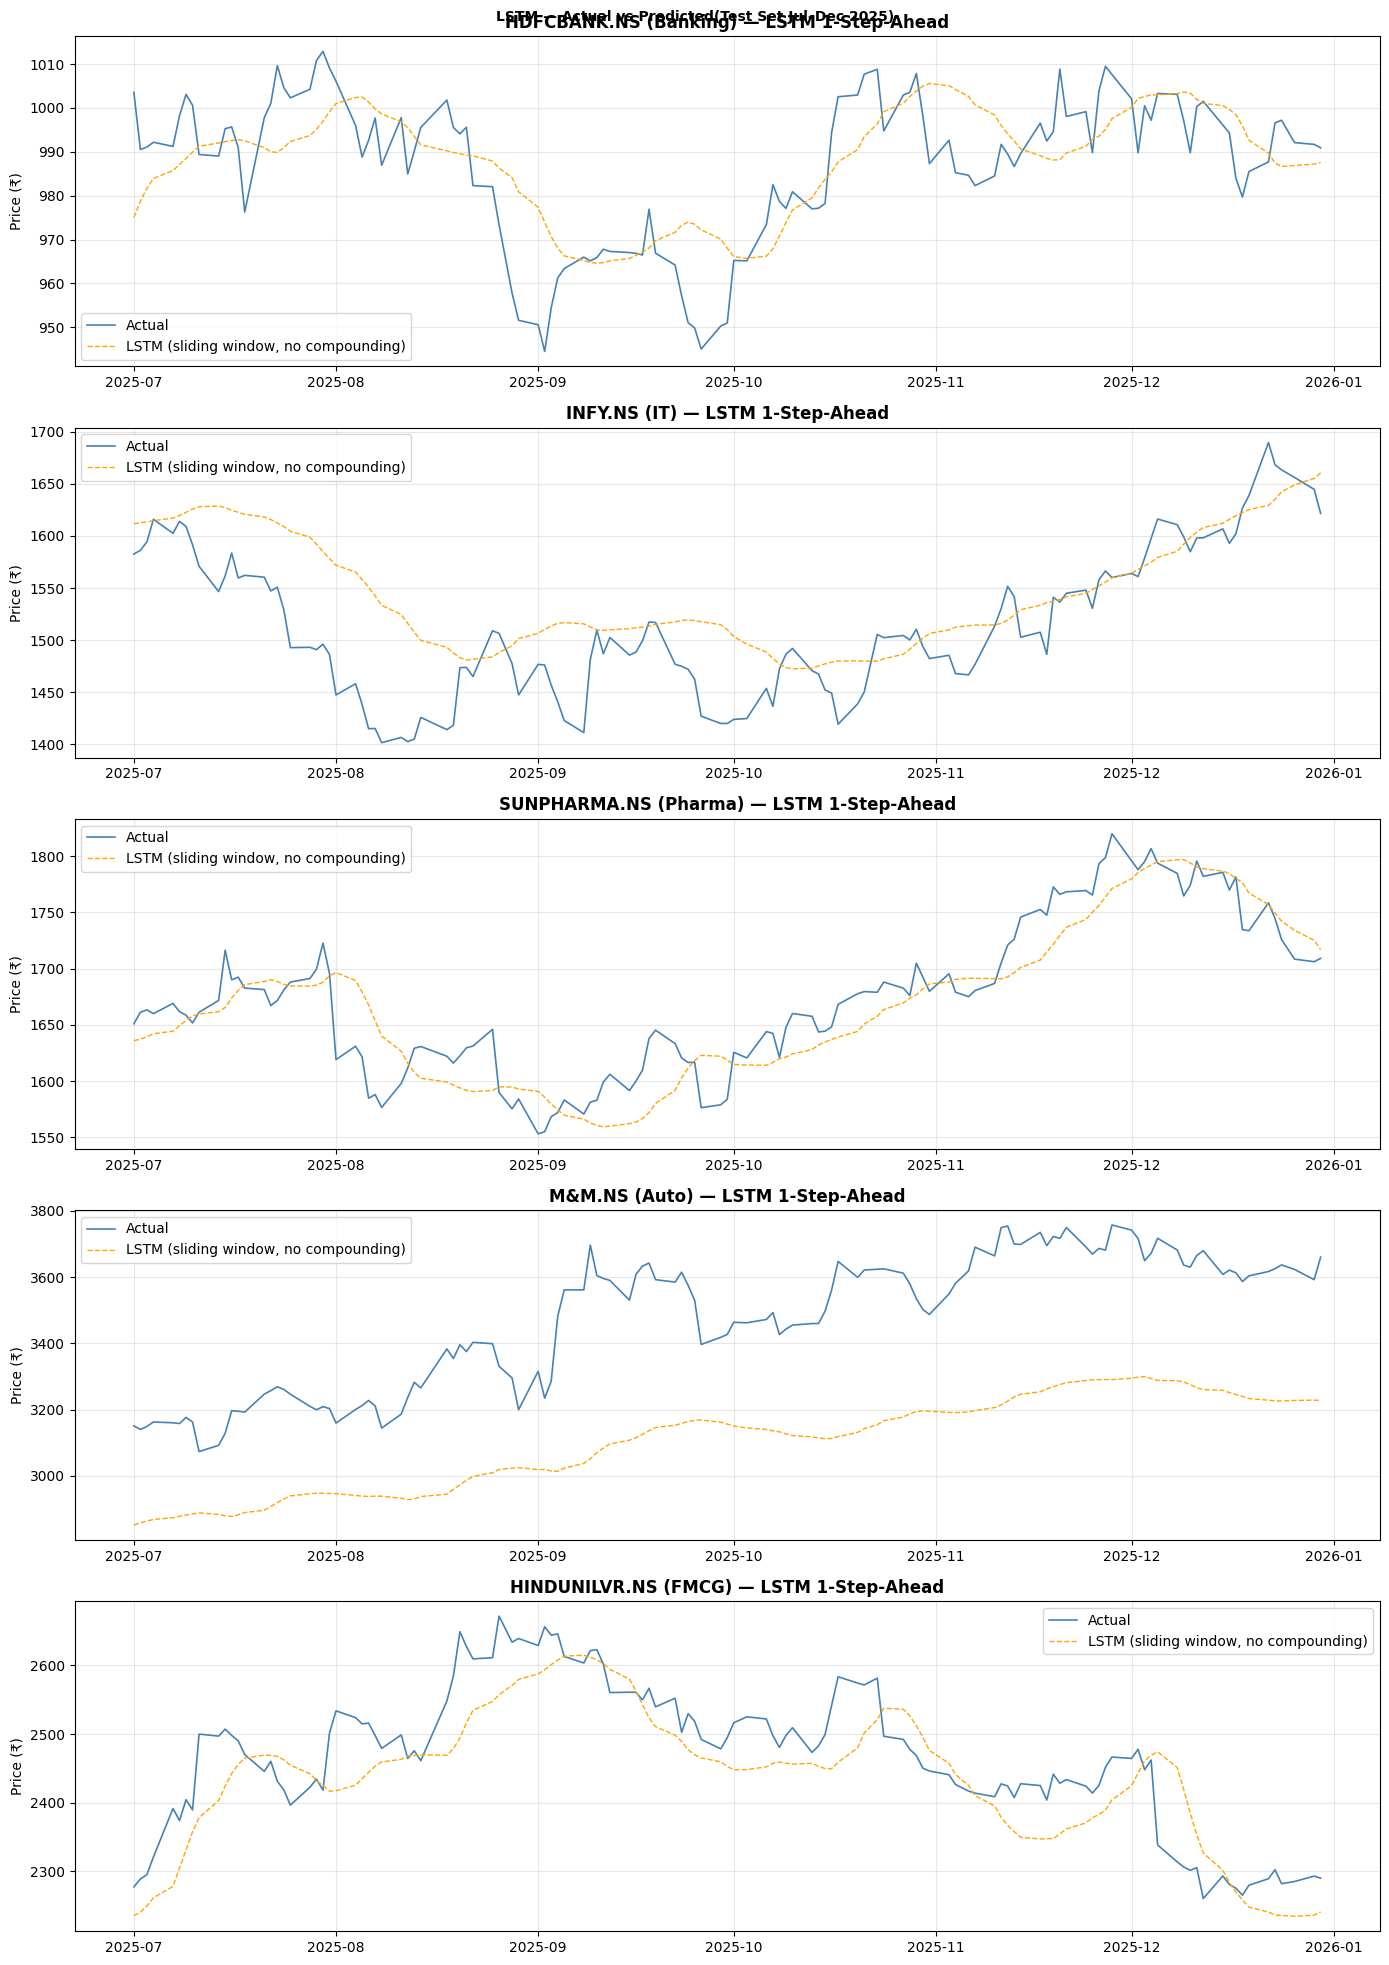

In [10]:
fig, axes = plt.subplots(len(TICKER_LIST), 1, figsize=(14, 4 * len(TICKER_LIST)), sharex=False)

for ax, ticker in zip(axes, TICKER_LIST):
    actual = test_close[ticker].dropna()
    preds  = lstm_test_preds[ticker]
    min_len = min(len(actual), len(preds))

    ax.plot(actual.index[:min_len], actual.values[:min_len], label='Actual', linewidth=1.2, color='steelblue')
    ax.plot(actual.index[:min_len], preds[:min_len], label='LSTM (sliding window, no compounding)', linewidth=1.0, color='orange', linestyle='--')
    ax.set_title(f'{ticker} ({SECTOR_MAP[ticker]}) — LSTM 1-Step-Ahead', fontweight='bold')
    ax.set_ylabel('Price (₹)')
    ax.legend()

plt.suptitle('LSTM — Actual vs Predicted(Test Set Jul–Dec 2025)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/08_lstm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Metrics Summary Table (Task 6 input)

In [11]:
metrics_df = pd.DataFrame(lstm_metrics)
print('LSTM Evaluation Metrics — Test Set (Jul–Dec 2025)')
print('='*60)
print(metrics_df.to_string(index=False))
print(f'\nAvg MAPE    : {metrics_df["MAPE (%)"].mean():.2f}%')
print(f'Avg RMSE    : {metrics_df["RMSE"].mean():.2f}')
print(f'Avg Dir Acc : {metrics_df["Dir Acc (%)"].mean():.1f}%')

metrics_df.to_csv('../outputs/forecasts/lstm_metrics.csv', index=False)

LSTM Evaluation Metrics — Test Set (Jul–Dec 2025)
        Stock  Sector  MAPE (%)     RMSE  Dir Acc (%)
  HDFCBANK.NS Banking    0.9143  11.4356        45.97
      INFY.NS      IT    2.7271  53.9197        44.35
 SUNPHARMA.NS  Pharma    1.4064  29.4169        44.35
       M&M.NS    Auto   10.6010 381.3221        32.26
HINDUNILVR.NS    FMCG    2.0113  59.9801        50.81

Avg MAPE    : 3.53%
Avg RMSE    : 107.21
Avg Dir Acc : 43.5%


---
## 9. Live 2-Day Forecast (Beyond Dec 2025)

In [12]:
live_forecasts = []
for ticker in TICKER_LIST:
    scaler   = price_scalers[ticker]
    full_s   = full_close[ticker].dropna()
    last_price = full_s.iloc[-1]
    
    # Clipping bounds - max 15% move either direction
    max_drop = last_price * 0.85
    max_rise = last_price * 1.15
    
    full_feat = compute_features(full_s)
    full_scaled = scaler.transform(full_feat[FEATURE_COLS].values)
    
    current_window = list(full_scaled[-LSTM_WINDOW:])
    day_preds_scaled = []
    
    for _ in range(FORECAST_HORIZON):
        x = np.array(current_window[-LSTM_WINDOW:]).reshape(1, LSTM_WINDOW, len(FEATURE_COLS))
        pred_s = lstm_models[ticker].predict(x, verbose=0)[0, 0]
        day_preds_scaled.append(pred_s)
        
        next_row = current_window[-1].copy()
        next_row[TARGET_IDX] = pred_s
        current_window.append(next_row)
    
    # Inverse transform
    dummy = np.zeros((FORECAST_HORIZON, len(FEATURE_COLS)))
    dummy[:, TARGET_IDX] = day_preds_scaled
    day_prices = scaler.inverse_transform(dummy)[:, 0]
    
    # ============ APPLY CLIPPING HERE ============
    day_prices = np.clip(day_prices, max_drop, max_rise)
    # =============================================
    
    live_forecasts.append({
        'Stock'             : ticker,
        'Sector'            : SECTOR_MAP[ticker],
        'Last Known Price'  : round(last_price, 2),
        'Forecast Day 1'    : round(day_prices[0], 2),
        'Forecast Day 2'    : round(day_prices[1], 2),
        'Pred Return D1 (%)': round((day_prices[0]-last_price)/last_price*100, 3),
        'Pred Return D2 (%)': round((day_prices[1]-last_price)/last_price*100, 3)
    })
live_df = pd.DataFrame(live_forecasts)
print('Live 2-Day LSTM Forecast (with 15% clipping):')
print(live_df.to_string(index=False))
live_df.to_csv('../outputs/forecasts/lstm_forecasts.csv', index=False)
print('\nSaved lstm_forecasts.csv')

Live 2-Day LSTM Forecast (with 15% clipping):
        Stock  Sector  Last Known Price  Forecast Day 1  Forecast Day 2  Pred Return D1 (%)  Pred Return D2 (%)
  HDFCBANK.NS Banking             990.9          987.93          988.24              -0.299              -0.268
      INFY.NS      IT            1621.6         1664.28         1667.60               2.632               2.837
 SUNPHARMA.NS  Pharma            1709.1         1709.92         1703.99               0.048              -0.299
       M&M.NS    Auto            3660.3         3232.14         3235.37             -11.697             -11.609
HINDUNILVR.NS    FMCG            2290.2         2246.85         2251.62              -1.893              -1.685

Saved lstm_forecasts.csv


---
## 10. Summary

In [13]:
print('='*30)
print('NOTEBOOK 03 — LSTM v3 SUMMARY')
print('='*30)
print(f'Architecture : LSTM(128) → Dropout → LSTM(64) → Dense(32) → Dense(1)')
print(f'Input        : ({LSTM_WINDOW} days, {len(FEATURE_COLS)} features)')
print(f'Features     : {FEATURE_COLS}')
print(f'Target       : next-day close price (scaled, no cumsum)')
print(f'Evaluation   : 1-step-ahead sliding window on actual history')
print()
print(metrics_df[['Stock','MAPE (%)','RMSE','Dir Acc (%)']].to_string(index=False))
print()
print('Live 2-day forecast:')
print(live_df[['Stock','Forecast Day 1','Forecast Day 2', 'Pred Return D1 (%)','Pred Return D2 (%)']].to_string(index=False))

NOTEBOOK 03 — LSTM v3 SUMMARY
Architecture : LSTM(128) → Dropout → LSTM(64) → Dense(32) → Dense(1)
Input        : (60 days, 8 features)
Features     : ['close', 'log_ret', 'rsi_14', 'macd', 'volatility_20', 'sma_20', 'sma_50', 'bb_position']
Target       : next-day close price (scaled, no cumsum)
Evaluation   : 1-step-ahead sliding window on actual history

        Stock  MAPE (%)     RMSE  Dir Acc (%)
  HDFCBANK.NS    0.9143  11.4356        45.97
      INFY.NS    2.7271  53.9197        44.35
 SUNPHARMA.NS    1.4064  29.4169        44.35
       M&M.NS   10.6010 381.3221        32.26
HINDUNILVR.NS    2.0113  59.9801        50.81

Live 2-day forecast:
        Stock  Forecast Day 1  Forecast Day 2  Pred Return D1 (%)  Pred Return D2 (%)
  HDFCBANK.NS          987.93          988.24              -0.299              -0.268
      INFY.NS         1664.28         1667.60               2.632               2.837
 SUNPHARMA.NS         1709.92         1703.99               0.048              -0.29

-----
## Prophet Model

In [14]:
from prophet import Prophet
prophet_metrics = []
prophet_test_preds = {}
for ticker in TICKER_LIST:
    print(f"\n{'='*55}")
    print(f"Prophet for: {ticker} ({SECTOR_MAP[ticker]})")
    print('='*55)
    prices = full_close[ticker].dropna()
    train_prices = train_close[ticker].dropna()
    test_prices  = test_close[ticker].dropna()
    # Prophet requires columns: 'ds' (datetime) and 'y' (value)
    train_df = pd.DataFrame({'ds': train_prices.index, 'y': train_prices.values})
    test_df  = pd.DataFrame({'ds': test_prices.index,  'y': test_prices.values})
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        changepoint_prior_scale=0.055
    )
    model.fit(train_df)
    forecast = model.predict(test_df)
    preds = forecast['yhat'].values
    # Clip predictions to avoid negative prices
    preds = np.clip(preds, preds.min() * 0.8, None)
    prophet_test_preds[ticker] = preds
    actual_vals = test_prices.values
    min_len = min(len(actual_vals), len(preds))
    m = {
        'Stock'      : ticker,
        'Sector'     : SECTOR_MAP[ticker],
        'MAPE (%)'   : round(mape(actual_vals[:min_len], preds[:min_len]), 4),
        'RMSE'       : round(rmse(actual_vals[:min_len], preds[:min_len]), 4),
        'Dir Acc (%)': round(directional_accuracy(actual_vals[:min_len], preds[:min_len]), 2)
    }
    prophet_metrics.append(m)
    print(f"  MAPE: {m['MAPE (%)']:.2f}%  |  RMSE: {m['RMSE']:.2f}  |  Dir Acc: {m['Dir Acc (%)']:.1f}%")

Importing plotly failed. Interactive plots will not work.



Prophet for: HDFCBANK.NS (Banking)


04:26:29 - cmdstanpy - INFO - Chain [1] start processing
04:26:29 - cmdstanpy - INFO - Chain [1] done processing
04:26:30 - cmdstanpy - INFO - Chain [1] start processing


  MAPE: 3.73%  |  RMSE: 42.55  |  Dir Acc: 54.8%

Prophet for: INFY.NS (IT)


04:26:30 - cmdstanpy - INFO - Chain [1] done processing
04:26:30 - cmdstanpy - INFO - Chain [1] start processing


...

  MAPE: 9.34%  |  RMSE: 174.80  |  Dir Acc: 59.7%

Prophet for: M&M.NS (Auto)


04:26:31 - cmdstanpy - INFO - Chain [1] done processing
04:26:31 - cmdstanpy - INFO - Chain [1] start processing


  MAPE: 6.31%  |  RMSE: 271.08  |  Dir Acc: 49.2%

Prophet for: HINDUNILVR.NS (FMCG)


04:26:31 - cmdstanpy - INFO - Chain [1] done processing


  MAPE: 3.16%  |  RMSE: 95.62  |  Dir Acc: 55.6%


-----
# 2-day Forecast

In [15]:
# Prophet 2-day forecast
prophet_forecasts = []
for ticker in TICKER_LIST:
    prices = full_close[ticker].dropna()
    last_price = prices.iloc[-1]
    model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
    model.fit(pd.DataFrame({'ds': prices.index, 'y': prices.values}))
    future = model.make_future_dataframe(periods=2, freq='B')
    fc = model.predict(future)
    day1 = fc['yhat'].iloc[-2]
    day2 = fc['yhat'].iloc[-1]
    prophet_forecasts.append({
        'Stock'             : ticker,
        'Sector'            : SECTOR_MAP[ticker],
        'Last Known Price'  : round(last_price, 2),
        'Forecast Day 1'    : round(day1, 2),
        'Forecast Day 2'    : round(day2, 2),
        'Pred Return D1 (%)': round((day1 - last_price) / last_price * 100, 3),
        'Pred Return D2 (%)': round((day2 - last_price) / last_price * 100, 3)
    })
prophet_fc_df = pd.DataFrame(prophet_forecasts)
print("\nProphet 2-Day Forecast:")
print(prophet_fc_df.to_string(index=False))
prophet_fc_df.to_csv('../outputs/forecasts/prophet_forecasts.csv', index=False)
pd.DataFrame(prophet_metrics).to_csv('../outputs/forecasts/prophet_metrics.csv', index=False)

04:26:39 - cmdstanpy - INFO - Chain [1] start processing
04:26:40 - cmdstanpy - INFO - Chain [1] done processing
04:26:40 - cmdstanpy - INFO - Chain [1] start processing
04:26:40 - cmdstanpy - INFO - Chain [1] done processing
04:26:41 - cmdstanpy - INFO - Chain [1] start processing
04:26:41 - cmdstanpy - INFO - Chain [1] done processing
04:26:41 - cmdstanpy - INFO - Chain [1] start processing
04:26:42 - cmdstanpy - INFO - Chain [1] done processing
04:26:42 - cmdstanpy - INFO - Chain [1] start processing
04:26:42 - cmdstanpy - INFO - Chain [1] done processing



Prophet 2-Day Forecast:
        Stock  Sector  Last Known Price  Forecast Day 1  Forecast Day 2  Pred Return D1 (%)  Pred Return D2 (%)
  HDFCBANK.NS Banking             990.9         1027.16         1026.06               3.660               3.548
      INFY.NS      IT            1621.6         1545.43         1543.85              -4.697              -4.795
 SUNPHARMA.NS  Pharma            1709.1         1692.91         1691.55              -0.947              -1.027
       M&M.NS    Auto            3660.3         3612.11         3614.14              -1.317              -1.261
HINDUNILVR.NS    FMCG            2290.2         2368.97         2367.67               3.439               3.383
